#**Association Rule Mining**
It is a type of unsupervised learning that helps finding the relationship between different items in any dataset. It identifies pattern like

if x happens, then y is likely to happen

**For example:** In a Supermarket, if many customers who buy bread also buy butter, the system will generate a rule:

if a customer buys bread, they are likely to buy butter

This helps business make decisions, such as placing bread and butter closer together to boost sales

#**There are three components of Association rule mining(ARM)**

**1. Support:** It is the frequency of an item or itemset appearing in the dataset

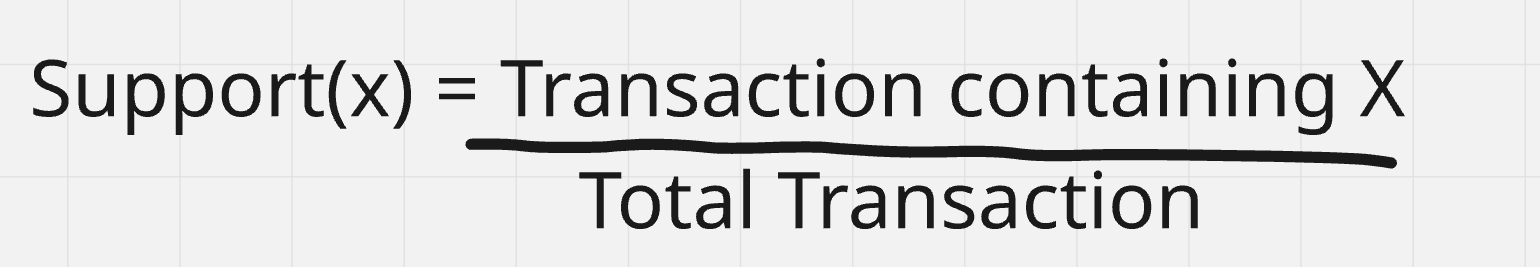

**Example:** If "Bread" appears 40 out of 100 transactions, the support for "Bread" is 40% or 0.4

**2. Confidence:** How often rule X -> Y is found to be true. It measures the reliablity of the rule

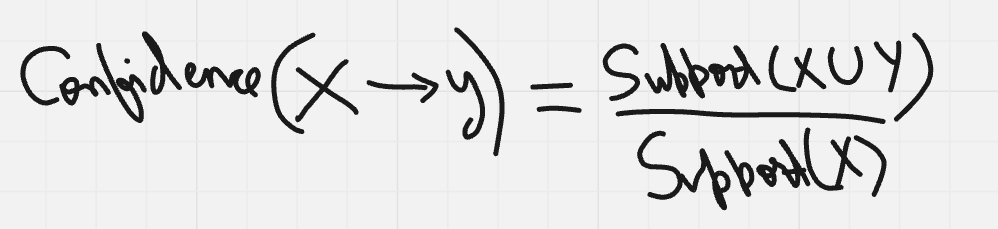

**Example:** if 30 out of 40 transaction containing bread also contain butter, then:

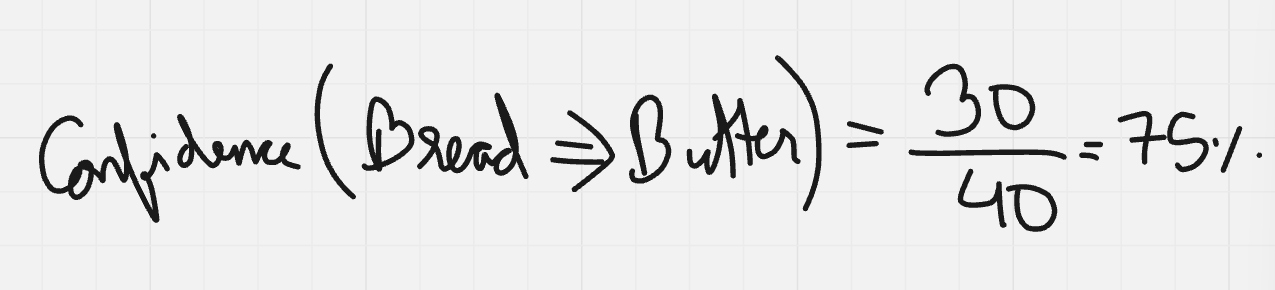

**3. Lift:** It tells you how much more likely y is to be bought when x is bought, compared to when y is bought independently. This will indicate the strength of association.

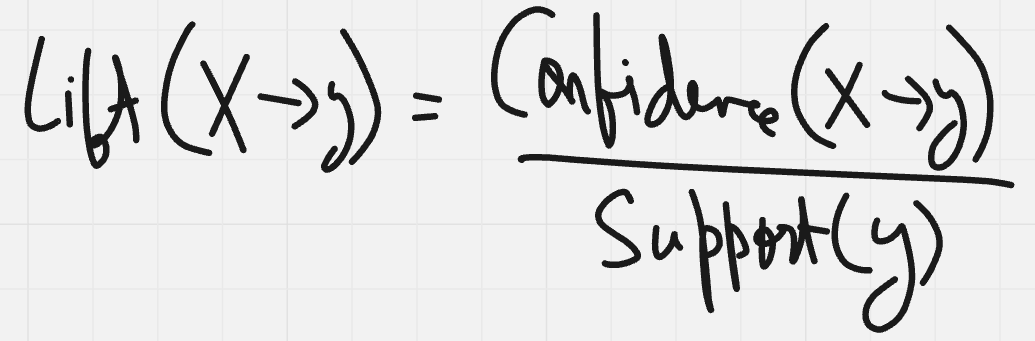

**Example:**

- If Confidence(Bread -> Butter) = 0.75
- and support(butter) = 0.5
- Then Lift = 0.75 / 0.5 = 1.5
- Since lift > 1, it means "Buying bread increases the likelihood of buying butter"

**Implementation**

In [ ]:
# We will create our own data

In [209]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [210]:
transactions = [
    ["milk",'Bread','Butter'],
    ['Bread','Butter'],
    ["milk",'Egg'],
    ["milk",'Bread','Egg'],
    ['Bread','Egg'],
    ["milk",'Bread','Butter',"Egg"],
    ["milk",'Bread'],
    ['Bread','Butter'],
]

In [211]:
# We will convert it into dataframe

df = pd.DataFrame([{item : (item in transaction) for item in ['milk','Bread','Butter','Egg']} for transaction in transactions])
df

,milk,Bread,Butter,Egg
0,True,True,True,False
1,False,True,True,False
2,True,False,False,True
3,True,True,False,True
4,False,True,False,True
5,True,True,True,True
6,True,True,False,False
7,False,True,True,False


Let's Create support function

In [212]:
def support(itemset,df):
  count = df[list(itemset)].all(axis=1).sum() # count the transaction where all the items were present
  return count/len(df)

support_bread = support({'Bread'},df)
print(f'support_bread : {support_bread :.2f}')

support_bread : 0.88


In [213]:
# x = {1,2,3,4}
# y = {3,4,5,6}
# x | y # Union

In [214]:
# We will create function for confidence

In [215]:
def confidence(X,Y,df):
  supportXY = support(X | Y, df)

  supportX = support(X,df)

  if supportX == 0:
    return 0

  return supportXY /supportX

In [216]:
confidence_of_Bread_butter = confidence({"Bread"},{"Butter"},df)
print(f'confidence_of_Bread_butter : {confidence_of_Bread_butter :.2f}')

confidence_of_Bread_butter : 0.57


**Now, we will create a function to implement Lift**

In [217]:
def lift(X,Y,df):
  conXY = confidence(X,Y,df)

  supportY = support(Y,df)

  if supportY == 0:
    return 0

  return conXY / supportY


In [218]:
print(f'Lift(Bread -> Butter): {lift({'Bread'},{'Butter'},df):.2f}')
print(f'Lift(Milk -> Bread): {lift({'milk'},{'Bread'},df):.2f}')
print(f'Lift(Bread -> Egg): {lift({'Bread'},{'Egg'},df):.2f}')

Lift(Bread -> Butter): 1.14
Lift(Milk -> Bread): 0.91
Lift(Bread -> Egg): 0.86


**Apriori Algorithm**

In [219]:
from mlxtend.frequent_patterns import apriori, association_rules

It finds frequent itemsets

In [220]:
frequentItemsets = apriori(df,min_support = 0.3,use_colnames = True)
frequentItemsets

,support,itemsets
0,0.625,(milk)
1,0.875,(Bread)
2,0.500,(Butter)
3,0.500,(Egg)
4,0.500,"(milk, Bread)"
5,0.375,"(milk, Egg)"
6,0.500,"(Butter, Bread)"
7,0.375,"(Egg, Bread)"


In [221]:
rules = association_rules(frequentItemsets, metric='confidence', min_threshold=0.6)

In [222]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(milk),(Bread),0.625,0.875,0.500,0.80,0.914286,1.0,-0.046875,0.625,-0.200000,0.500000,-0.600000,0.685714
1,(milk),(Egg),0.625,0.500,0.375,0.60,1.200000,1.0,0.062500,1.250,0.444444,0.500000,0.200000,0.675000
2,(Egg),(milk),0.500,0.625,0.375,0.75,1.200000,1.0,0.062500,1.500,0.333333,0.500000,0.333333,0.675000
3,(Butter),(Bread),0.500,0.875,0.500,1.00,1.142857,1.0,0.062500,inf,0.250000,0.571429,1.000000,0.785714
4,(Egg),(Bread),0.500,0.875,0.375,0.75,0.857143,1.0,-0.062500,0.500,-0.250000,0.375000,-1.000000,0.589286


In [223]:
!pip install apyori

In [224]:
import apyori

In [225]:
#let's implement on a dataset

In [226]:
df = pd.read_csv('/content/Groceries_dataset.csv')
df

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [227]:
df.shape

(38765, 3)

In [228]:
df.isnull().sum()

,0
Member_number,0
Date,0
itemDescription,0


In [229]:
x = df['itemDescription'].nunique()
print(f'Total number of item available: {x}')

Total number of item available: 167


In [230]:
a = df['itemDescription'].unique()
a

array(['tropical fruit', 'whole milk', 'pip fruit', 'other vegetables',
       'rolls/buns', 'pot plants', 'citrus fruit', 'beef', 'frankfurter',
       'chicken', 'butter', 'fruit/vegetable juice',
       'packaged fruit/vegetables', 'chocolate', 'specialty bar',
       'butter milk', 'bottled water', 'yogurt', 'sausage', 'brown bread',
       'hamburger meat', 'root vegetables', 'pork', 'pastry',
       'canned beer', 'berries', 'coffee', 'misc. beverages', 'ham',
       'turkey', 'curd cheese', 'red/blush wine',
       'frozen potato products', 'flour', 'sugar', 'frozen meals',
       'herbs', 'soda', 'detergent', 'grapes', 'processed cheese', 'fish',
       'sparkling wine', 'newspapers', 'curd', 'pasta', 'popcorn',
       'finished products', 'beverages', 'bottled beer', 'dessert',
       'dog food', 'specialty chocolate', 'condensed milk', 'cleaner',
       'white wine', 'meat', 'ice cream', 'hard cheese', 'cream cheese ',
       'liquor', 'pickled vegetables', 'liquor (appetizer

In [231]:
#We will perfrom one hot encoding

In [232]:
encoded = pd.get_dummies(df['itemDescription'])

In [233]:
encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [234]:
df = df.drop('itemDescription',axis = 1)

In [235]:
df.head()

,Member_number,Date
0,1808,21-07-2015
1,2552,05-01-2015
2,2300,19-09-2015
3,1187,12-12-2015
4,3037,01-02-2015


In [236]:
df = df.join(encoded)

In [237]:
df.head()

,Member_number,Date,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,1808,21-07-2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2552,05-01-2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,2300,19-09-2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1187,12-12-2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3037,01-02-2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False



Transactions, even if a customer has bought multiple items on the same day, still we would be considering the same as one transaction

In [238]:
a

array(['tropical fruit', 'whole milk', 'pip fruit', 'other vegetables',
       'rolls/buns', 'pot plants', 'citrus fruit', 'beef', 'frankfurter',
       'chicken', 'butter', 'fruit/vegetable juice',
       'packaged fruit/vegetables', 'chocolate', 'specialty bar',
       'butter milk', 'bottled water', 'yogurt', 'sausage', 'brown bread',
       'hamburger meat', 'root vegetables', 'pork', 'pastry',
       'canned beer', 'berries', 'coffee', 'misc. beverages', 'ham',
       'turkey', 'curd cheese', 'red/blush wine',
       'frozen potato products', 'flour', 'sugar', 'frozen meals',
       'herbs', 'soda', 'detergent', 'grapes', 'processed cheese', 'fish',
       'sparkling wine', 'newspapers', 'curd', 'pasta', 'popcorn',
       'finished products', 'beverages', 'bottled beer', 'dessert',
       'dog food', 'specialty chocolate', 'condensed milk', 'cleaner',
       'white wine', 'meat', 'ice cream', 'hard cheese', 'cream cheese ',
       'liquor', 'pickled vegetables', 'liquor (appetizer

* We are grouping purchases made by each customers (Member number) on each date (Date)
* .apply(sum) sums up the same item bought by the same customer on the same date

In [239]:
records = df.groupby(['Member_number','Date'])[a].apply(sum)

In [240]:
records.iloc[1]

,1000
,24-06-2014
tropical fruit,0
whole milk,1
pip fruit,0
other vegetables,0
rolls/buns,0
...,...
pudding powder,0
ready soups,0
make up remover,0


In [241]:
records = records.reset_index()[a]

In [242]:
records.head()

,tropical fruit,whole milk,pip fruit,other vegetables,rolls/buns,pot plants,citrus fruit,beef,frankfurter,chicken,...,flower (seeds),rice,tea,salad dressing,specialty vegetables,pudding powder,ready soups,make up remover,toilet cleaner,preservation products
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [243]:
records.shape

(14963, 167)

In [244]:
records.values

array([[0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [245]:
records.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14963 entries, 0 to 14962
Columns: 167 entries, tropical fruit to preservation products
dtypes: int64(167)
memory usage: 19.1 MB


In [247]:
for col in records.columns:
  records[col] = records[col].astype(int)

In [248]:
def get_prod_name(x):
  for product in a:
    if x[product] > 0:
      x[product] = product  # Replace the integer value with the product name
  return x

In [249]:
records = records.apply(get_prod_name, axis =1)
records

,tropical fruit,whole milk,pip fruit,other vegetables,rolls/buns,pot plants,citrus fruit,beef,frankfurter,chicken,...,flower (seeds),rice,tea,salad dressing,specialty vegetables,pudding powder,ready soups,make up remover,toilet cleaner,preservation products
0,0,whole milk,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,whole milk,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14958,tropical fruit,0,0,other vegetables,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14959,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14960,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14961,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [250]:
x = records.values
x

array([[0, 'whole milk', 0, ..., 0, 0, 0],
       [0, 'whole milk', 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=object)

In [252]:
x.shape

(14963, 167)

sub[sub!= 0 ] = Remove allf 0 values from sub

In [253]:
transactions = []

for sub in x:
  nonzerovalues = sub[sub!=0].tolist()
  if nonzerovalues:
    transactions.append(nonzerovalues)


Now our transacrions will be simplfied from the dataset

In [254]:
transactions

[['whole milk', 'yogurt', 'sausage', 'semi-finished bread'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables'],
 ['frankfurter', 'curd'],
 ['whole milk', 'rolls/buns', 'sausage'],
 ['whole milk', 'soda'],
 ['beef', 'white bread'],
 ['frankfurter', 'soda', 'whipped/sour cream'],
 ['other vegetables', 'frozen vegetables'],
 ['whole milk', 'butter'],
 ['tropical fruit', 'sugar'],
 ['butter milk', 'specialty chocolate'],
 ['rolls/buns', 'sausage'],
 ['root vegetables', 'detergent'],
 ['frozen meals', 'dental care'],
 ['rolls/buns'],
 ['dish cleaner', 'cling film/bags'],
 ['canned beer', 'frozen fish'],
 ['other vegetables', 'hygiene articles'],
 ['tropical fruit', 'whole milk', 'pip fruit'],
 ['rolls/buns', 'chocolate', 'red/blush wine'],
 ['other vegetables', 'shopping bags'],
 ['whole milk', 'rolls/buns', 'packaged fruit/vegetables', 'chocolate'],
 ['whole milk', 'root vegetables', 'pastry'],
 

You can set values based on dataset size and business needs:
* Large Datasets -> Higher min_support to reduce noise
* Strict rules -> Higher the min_confidance and min_lift
* explore weak patterns -> lower values

In [259]:
rules = apyori.apriori(transactions,min_support = 0.0003,min_confidence = 0.05,min_lift = 4,min_length = 2, target = 'rules')

In [260]:
association_results = list(rules)
association_results

[RelationRecord(items=frozenset({'seasonal products', 'soups'}), support=0.0003341575887188398, ordered_statistics=[OrderedStatistic(items_base=frozenset({'soups'}), items_add=frozenset({'seasonal products'}), confidence=0.10416666666666667, lift=14.704205974842768)]),
 RelationRecord(items=frozenset({'brown bread', 'frozen vegetables', 'canned beer'}), support=0.0003341575887188398, ordered_statistics=[OrderedStatistic(items_base=frozenset({'brown bread', 'canned beer'}), items_add=frozenset({'frozen vegetables'}), confidence=0.1388888888888889, lift=4.959891275523733), OrderedStatistic(items_base=frozenset({'brown bread', 'frozen vegetables'}), items_add=frozenset({'canned beer'}), confidence=0.35714285714285715, lift=7.612433862433862), OrderedStatistic(items_base=frozenset({'canned beer', 'frozen vegetables'}), items_add=frozenset({'brown bread'}), confidence=0.25, lift=6.644316163410303)]),
 RelationRecord(items=frozenset({'sausage', 'brown bread', 'canned beer'}), support=0.00040

In [263]:
val1 = association_results[0]
val1

RelationRecord(items=frozenset({'seasonal products', 'soups'}), support=0.0003341575887188398, ordered_statistics=[OrderedStatistic(items_base=frozenset({'soups'}), items_add=frozenset({'seasonal products'}), confidence=0.10416666666666667, lift=14.704205974842768)])

In [264]:
val1[0]

frozenset({'seasonal products', 'soups'})

In [266]:
val1[1]

0.0003341575887188398

In [267]:
val1[2]

[OrderedStatistic(items_base=frozenset({'soups'}), items_add=frozenset({'seasonal products'}), confidence=0.10416666666666667, lift=14.704205974842768)]

In [268]:
val1[2][0][2]

0.10416666666666667

In [269]:
val1[2][0][3]

14.704205974842768

Let's see the results for entire set of transactions

In [272]:
for item in association_results:

  pair = item[0]
  items = [x for x in pair]
  print("Rule " + str(items[0]) + " ->" + str(items[1]))
  print("support " + str(item[1]))
  print("confidence " + str(item[2][0][2]))
  print("Lift " + str(item[2][0][3]))
  print('================================')

Rule seasonal products ->soups
support 0.0003341575887188398
confidence 0.10416666666666667
Lift 14.704205974842768
Rule brown bread ->frozen vegetables
support 0.0003341575887188398
confidence 0.1388888888888889
Lift 4.959891275523733
Rule sausage ->brown bread
support 0.00040098910646260775
confidence 0.2222222222222222
Lift 4.736625514403292
Rule yogurt ->butter milk
support 0.0003341575887188398
confidence 0.4166666666666667
Lift 4.851815823605707
Rule sausage ->canned beer
support 0.0003341575887188398
confidence 0.25
Lift 4.142580287929125
Rule whole milk ->canned beer
support 0.00040098910646260775
confidence 0.06666666666666667
Lift 4.866016260162602
Rule soda ->yogurt
support 0.00040098910646260775
confidence 0.39999999999999997
Lift 4.657743190661479
Rule sausage ->pastry
support 0.0003341575887188398
confidence 0.25
Lift 4.833010335917313
Rule sausage ->curd
support 0.0003341575887188398
confidence 0.5
Lift 8.28516057585825
Rule sausage ->curd
support 0.0003341575887188398
c